# Kiến trúc
- Input (1×28×28) ảnh xám kích thước 28x28
- → Conv (6×28×28) convolution layer với 6 kernel size 5x5, padding = 2
- → Pool (6×14×14) avg pooling kernel 2x2, stride = 2
- → Conv (16×10×10) convolution layer với 16 kernel size 5x5
- → Pool (16×5×5) avg pooling kernel 2x3, stride = 2
- → Flatten (400) nếu train theo batch sẽ là (batch_size, 400): 400 = 16x5x5
- → FC (120): 400 - 120
- → FC (84): 120 - 84
- → FC (10): 84 - 10 - từ số 0 đến 9, dùng softmax để phân loại

In [1]:
import torch
from torch import nn

In [21]:
class LeNet(nn.Module):
    def __init__(self, num_class):
        super(LeNet, self).__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(out_channels=6, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(out_channels=16, kernel_size=5), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(out_features=120), nn.ReLU(),
            nn.LazyLinear(out_features=84), nn.ReLU(),
            nn.LazyLinear(out_features=num_class)
        )
        
    def layer_summary(self, X_shape):
        X = torch.randn(X_shape)
        for layer in self.net:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)

    def forward(self, X):
        return self.net(X)

In [22]:
model = LeNet(10)
model.layer_summary((1, 1, 28, 28))

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
ReLU output shape:	 torch.Size([1, 6, 28, 28])
MaxPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
ReLU output shape:	 torch.Size([1, 16, 10, 10])
MaxPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
ReLU output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
ReLU output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


In [13]:
import torchvision
from torchvision import transforms

trans = torchvision.transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])

data_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=trans,
    download=True)
data_val = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=trans,
    download=True
)

len(data_train), len(data_val)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.44MB/s]


(60000, 10000)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    data_train,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    data_val,
    batch_size=128,
    shuffle=False
)

In [23]:
from torch import optim

model = LeNet(10)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(params=model.parameters(), lr=0.01)

epochs = 20

loss_histoty = {"train": [], "val": []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        y_hat = model(X_batch)

        loss = criterion(y_hat, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
    train_loss_avg = train_loss / len(train_loader)
    loss_histoty["train"].append(train_loss_avg)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            val_loss += loss.item()
        
        val_loss_avg = val_loss / len(val_loader)
        loss_histoty["val"].append(val_loss_avg)
    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss_avg}, Val Loss: {val_loss_avg}")





Epoch 1/20: Train Loss: 2.10447496277437, Val Loss: 0.9483475726880845
Epoch 2/20: Train Loss: 0.4294936909540884, Val Loss: 0.24774980153532544
Epoch 3/20: Train Loss: 0.2266977126918622, Val Loss: 0.1920239828989669
Epoch 4/20: Train Loss: 0.15812642530583815, Val Loss: 0.1290697816649606
Epoch 5/20: Train Loss: 0.1228512189746189, Val Loss: 0.11205553001676728
Epoch 6/20: Train Loss: 0.10065269769072088, Val Loss: 0.08290332684865827
Epoch 7/20: Train Loss: 0.08778545203438001, Val Loss: 0.07531618602220919
Epoch 8/20: Train Loss: 0.0781424728267864, Val Loss: 0.060126867040007075
Epoch 9/20: Train Loss: 0.07017637978840087, Val Loss: 0.06056527798282795
Epoch 10/20: Train Loss: 0.06516512844196237, Val Loss: 0.05851676486855948
Epoch 11/20: Train Loss: 0.05981537211499711, Val Loss: 0.05673120415313125
Epoch 12/20: Train Loss: 0.05592009527678254, Val Loss: 0.06782581049318286
Epoch 13/20: Train Loss: 0.05244821376665664, Val Loss: 0.05216466537754609
Epoch 14/20: Train Loss: 0.048

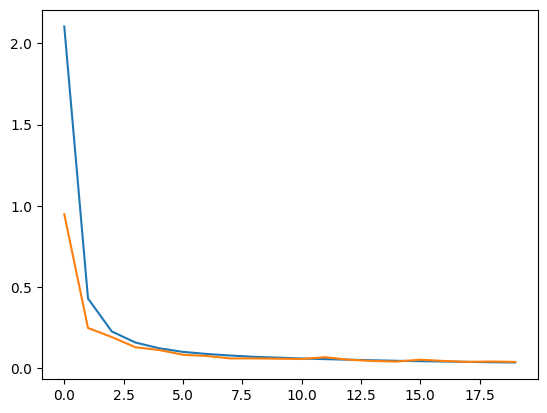

In [25]:
from matplotlib import pyplot as plt

plt.plot(loss_histoty["train"], label="train_loss")
plt.plot(loss_histoty["val"], label = "val_loss")

plt.show()

In [24]:
from sklearn.metrics import classification_report

# Tính toán predictions trên tất cả validation data
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        
        y_hat = model.forward(X_batch)
        predictions = y_hat.argmax(dim=1)
        
        y_true.extend(y_batch)
        y_pred.extend(predictions)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

